<a href="https://colab.research.google.com/github/Sou963/LSD-for-research/blob/main/LSD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving archive.zip to archive.zip


In [ ]:
import zipfile
import os

zip_file = "archive.zip"

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall("dataset")

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

print("My Drive folders:")
print(os.listdir('/content/drive/MyDrive'))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
My Drive folders:
['IMG_20220506_193920_466.jpg', 'IMG_20220506_193910_477.jpg', 'IMG_20220506_193909_072.jpg', 'IMG_20220506_193907_601.jpg', 'IMG_20220506_193823_379.jpg', 'IMG_20220506_193754_603.jpg', 'IMG_20220506_193727_022.jpg', 'IMG_20220506_193747_386.jpg', 'IMG_20220506_193713_251.jpg', 'IMG_20220506_193706_889.jpg', 'IMG_20220506_193656_941.jpg', 'IMG_20220506_193703_370.jpg', 'IMG_20220506_193642_609.jpg', 'IMG_20220506_193552_354.jpg', 'IMG_20220506_193540_352.jpg', 'IMG_20220506_192452_646.jpg', 'IMG_20220506_192440_055.jpg', 'IMG_20220506_192426_157.jpg', 'IMG_20220506_192149_829.jpg', 'IMG_20220506_192101_672.jpg', 'IMG-20220505-WA0082 (2).jpg', 'IMG-20220505-WA0082 (1).jpg', 'Polish_20220505_230910385 (1).jpg', 'Polish_20220505_231039152.jpg', 'Polish_20220505_204311151.jpg', 'Polish_20220505_201807683.jpg', 'Polish_20220505_201716194.jpg', '

In [ ]:
import os

healthy_path = "/content/drive/MyDrive/LSD_dataset/healthycows"
lumpy_path = "/content/drive/MyDrive/LSD_dataset/lumpycows"

print("Healthy folder exists:", os.path.exists(healthy_path))
print("Lumpy folder exists:", os.path.exists(lumpy_path))

if os.path.exists(healthy_path):
    print("Healthy files:", len(os.listdir(healthy_path)))

if os.path.exists(lumpy_path):
    print("Lumpy files:", len(os.listdir(lumpy_path)))

Healthy folder exists: True
Lumpy folder exists: True
Healthy files: 515
Lumpy files: 421


In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

healthy_path = "/content/drive/MyDrive/LSD_dataset/healthycows"
lumpy_path = "/content/drive/MyDrive/LSD_dataset/lumpycows"

def count_images(folder_path):
    count = 0

    for root, dirs, files in os.walk(folder_path):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png', '.webp')):
                count += 1

    return count

healthy_count = count_images(healthy_path)
lumpy_count = count_images(lumpy_path)

print("Healthy cows:", healthy_count)
print("Lumpy cows:", lumpy_count)
print("Total images:", healthy_count + lumpy_count)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Healthy cows: 515
Lumpy cows: 421
Total images: 936


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_dataset = tf.keras.utils.image_dataset_from_directory(
    "dataset",
    validation_split=0.20,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

temp_dataset = tf.keras.utils.image_dataset_from_directory(
    "dataset",
    validation_split=0.20,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

print("Classes:", train_dataset.class_names)

# Split temporary dataset into validation and test
temp_batches = tf.data.experimental.cardinality(temp_dataset)
validation_batches = temp_batches // 2

validation_dataset = temp_dataset.take(validation_batches)
test_dataset = temp_dataset.skip(validation_batches)

print("Train batches:", tf.data.experimental.cardinality(train_dataset))
print("Validation batches:", tf.data.experimental.cardinality(validation_dataset))
print("Test batches:", tf.data.experimental.cardinality(test_dataset))

Found 936 files belonging to 2 classes.
Using 749 files for training.
Found 936 files belonging to 2 classes.
Using 187 files for validation.
Classes: ['healthycows', 'lumpycows']
Train batches: tf.Tensor(24, shape=(), dtype=int64)
Validation batches: tf.Tensor(3, shape=(), dtype=int64)
Test batches: tf.Tensor(3, shape=(), dtype=int64)


In [ ]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
output = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=output)

In [ ]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=10
)

Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 39s 786ms/step - accuracy: 0.6088 - loss: 0.6965 - val_accuracy: 0.6250 - val_loss: 0.6896
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.7383 - loss: 0.5394 - val_accuracy: 0.5938 - val_loss: 0.7228
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.7450 - loss: 0.5052 - val_accuracy: 0.6875 - val_loss: 0.5847
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.7717 - loss: 0.4662 - val_accuracy: 0.6979 - val_loss: 0.5728
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8198 - loss: 0.4211 - val_accuracy: 0.6354 - val_loss: 0.6717
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.8358 - loss: 0.3819 - val_accuracy: 0.5938 - val_loss: 0.6877
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.8558 - loss: 0.3604 - val_accuracy: 0.5729 - val_loss: 0.6972
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.8705 - loss: 0.3289 - val_accuracy: 0.6771 -

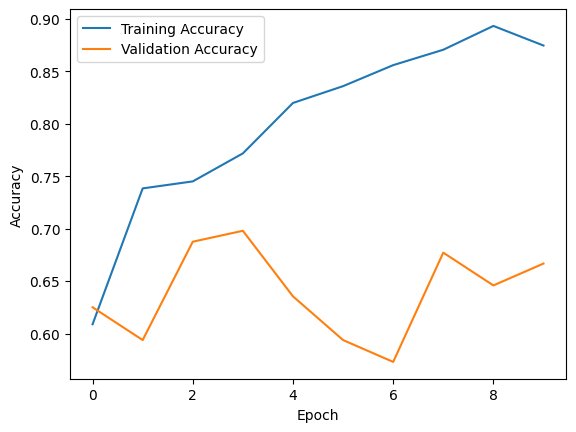

In [ ]:
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

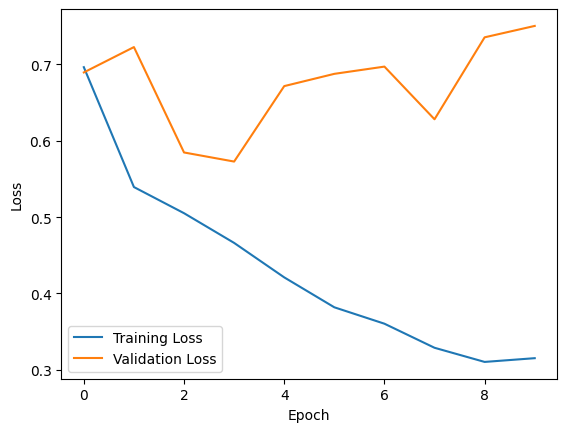

In [ ]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

Dataset extracted successfully!
Found 936 files belonging to 2 classes.
Using 749 files for training.
Found 936 files belonging to 2 classes.
Using 187 files for validation.
Classes found: ['healthycows', 'lumpycows'] -> Mapped to: ['Healthy', 'Lumpy']

Starting Stage 1: Training Head...
Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 14s 133ms/step - accuracy: 0.7009 - loss: 0.6217 - val_accuracy: 0.8125 - val_loss: 0.4730
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.8184 - loss: 0.4145 - val_accuracy: 0.8125 - val_loss: 0.4155
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.8678 - loss: 0.3159 - val_accuracy: 0.8646 - val_loss: 0.3324
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.8758 - loss: 0.3021 - val_accuracy: 0.8542 - val_loss: 0.3274
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.8838 - loss: 0.2738 - val_accuracy: 0.8542 - val_loss: 0.3214
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.9039 - lo

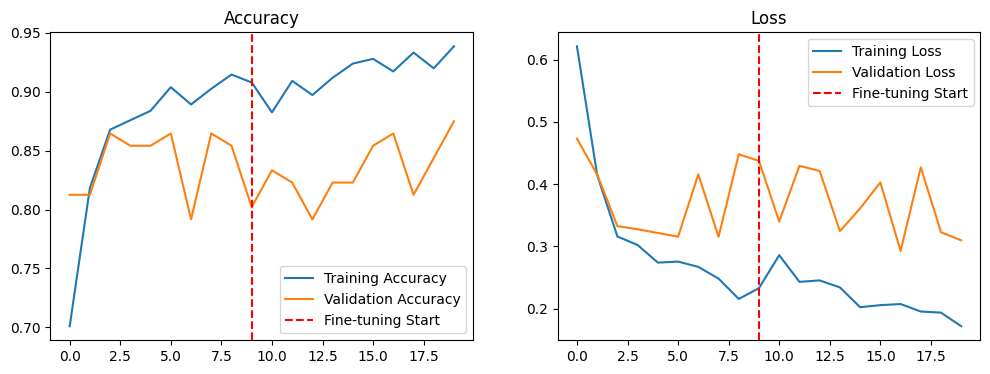


Classification Report:
              precision    recall  f1-score   support

     Healthy       0.85      0.81      0.83        57
       Lumpy       0.70      0.76      0.73        34

    accuracy                           0.79        91
   macro avg       0.78      0.79      0.78        91
weighted avg       0.80      0.79      0.79        91



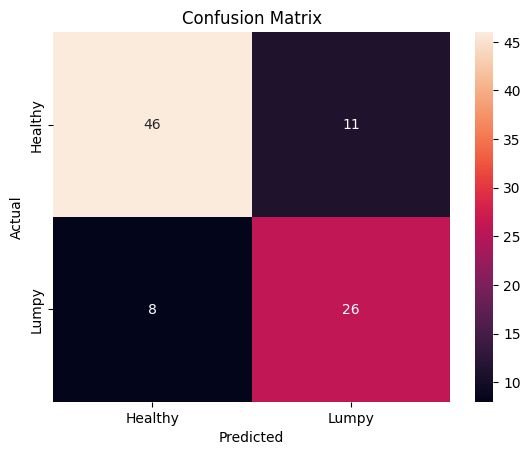

In [ ]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# --- 1. Data Loading & Extraction ---
# (Assuming archive.zip is already uploaded as per your previous steps)
if os.path.exists('archive.zip'):
    with zipfile.ZipFile("archive.zip", "r") as zip_ref:
        zip_ref.extractall("dataset")
    print("Dataset extracted successfully!")

# --- 2. Dataset Preparation (80/10/10 Split) ---
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# Initial 80% Train, 20% Temp
train_ds = tf.keras.utils.image_dataset_from_directory(
    "dataset",
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    "dataset",
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Split Temp into 50% Val, 50% Test (10% total each)
temp_batches = tf.data.experimental.cardinality(temp_ds)
val_batches = temp_batches // 2
val_ds = temp_ds.take(val_batches)
test_ds = temp_ds.skip(val_batches)

class_names = ['Healthy', 'Lumpy']
print(f"Classes found: {train_ds.class_names} -> Mapped to: {class_names}")

# --- 3. Data Augmentation & Preprocessing ---
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

# --- 4. Model Architecture ---
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights="imagenet")
base_model.trainable = False  # Freeze base

inputs = layers.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = preprocess_input(x) # Proper MobileNetV2 scaling (-1 to 1)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x) # Regularization
outputs = layers.Dense(1, activation="sigmoid")(x)

model = models.Model(inputs, outputs)

# --- 5. Stage 1: Training Top Layers ---
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss="binary_crossentropy", metrics=["accuracy"])

print("\nStarting Stage 1: Training Head...")
history_stage1 = model.fit(train_ds, validation_data=val_ds, epochs=10)

# --- 6. Stage 2: Fine-Tuning ---
base_model.trainable = True
# Freeze everything except the last 30 layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), # Small LR for fine-tuning
              loss="binary_crossentropy", metrics=["accuracy"])

print("\nStarting Stage 2: Fine-Tuning last 30 layers...")
history_stage2 = model.fit(train_ds, validation_data=val_ds, epochs=10)

# Combine histories for plotting
acc = history_stage1.history['accuracy'] + history_stage2.history['accuracy']
val_acc = history_stage1.history['val_accuracy'] + history_stage2.history['val_accuracy']
loss = history_stage1.history['loss'] + history_stage2.history['loss']
val_loss = history_stage1.history['val_loss'] + history_stage2.history['val_loss']

# --- 7. Evaluation ---
print("\nEvaluating on Test Set...")
results = model.evaluate(test_ds)
print(f"Test Loss: {results[0]:.4f}")
print(f"Test Accuracy: {results[1]:.4f}")
print(f"Test Accuracy Percentage: {results[1]*100:.2f}%")

# Save Model
model.save("lumpy_skin_disease_mobilenetv2.keras")

# --- 8. Visualizations ---
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.axvline(x=9, color='r', linestyle='--', label='Fine-tuning Start')
plt.legend(); plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.axvline(x=9, color='r', linestyle='--', label='Fine-tuning Start')
plt.legend(); plt.title('Loss')
plt.show()

# --- 9. Metrics Report ---
y_true, y_pred = [], []
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend((preds > 0.5).astype(int).flatten())

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix')
plt.show()

In [ ]:
test_loss, test_accuracy = model.evaluate(test_dataset, verbose=0)

print("Total Test Accuracy: {:.2f}%".format(test_accuracy * 100))

Total Test Accuracy: 82.42%


In [ ]:
import tensorflow as tf
test_loss, test_accuracy = model.evaluate(test_dataset)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy Percentage:", test_accuracy * 100)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.8352 - loss: 0.3818
Test Loss: 0.3818155527114868
Test Accuracy: 0.8351648449897766
Test Accuracy Percentage: 83.51648449897766


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend((predictions > 0.5).astype(int).flatten())

print(classification_report(
    y_true,
    y_pred,
    target_names=["Healthy", "Lumpy"]
))

              precision    recall  f1-score   support

     Healthy       0.84      0.81      0.83        53
       Lumpy       0.75      0.79      0.77        38

    accuracy                           0.80        91
   macro avg       0.80      0.80      0.80        91
weighted avg       0.80      0.80      0.80        91



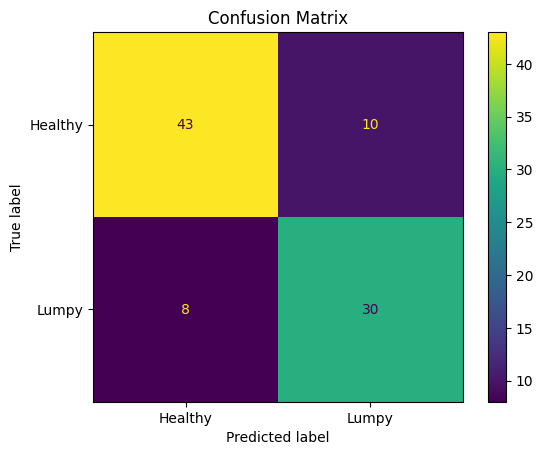

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Healthy", "Lumpy"]
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [ ]:
history_stage1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)
history_stage2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - accuracy: 0.9439 - loss: 0.1658 - val_accuracy: 0.8646 - val_loss: 0.4064
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step - accuracy: 0.9319 - loss: 0.1718 - val_accuracy: 0.8125 - val_loss: 0.4428
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - accuracy: 0.9239 - loss: 0.1773 - val_accuracy: 0.8125 - val_loss: 0.4964
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 0.9399 - loss: 0.1622 - val_accuracy: 0.8333 - val_loss: 0.4110
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.9413 - loss: 0.1716 - val_accuracy: 0.7917 - val_loss: 0.5014
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.9386 - loss: 0.1697 - val_accuracy: 0.8333 - val_loss: 0.3143
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - accuracy: 0.9399 - loss: 0.1550 - val_accuracy: 0.8646 - val_loss: 0.2876
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - accuracy: 0.9533 - loss: 0.1425 - val_accuracy: 0.8750 - v

In [ ]:
# Combine Stage 1 + Stage 2 histories

acc = (
    history_stage1.history['accuracy']
    + history_stage2.history['accuracy']
)

val_acc = (
    history_stage1.history['val_accuracy']
    + history_stage2.history['val_accuracy']
)

loss = (
    history_stage1.history['loss']
    + history_stage2.history['loss']
)

val_loss = (
    history_stage1.history['val_loss']
    + history_stage2.history['val_loss']
)

print("Total epochs:", len(acc))
print("Final Training Accuracy:", acc[-1] * 100)
print("Final Validation Accuracy:", val_acc[-1] * 100)

Total epochs: 20
Final Training Accuracy: 97.46328592300415
Final Validation Accuracy: 85.41666865348816


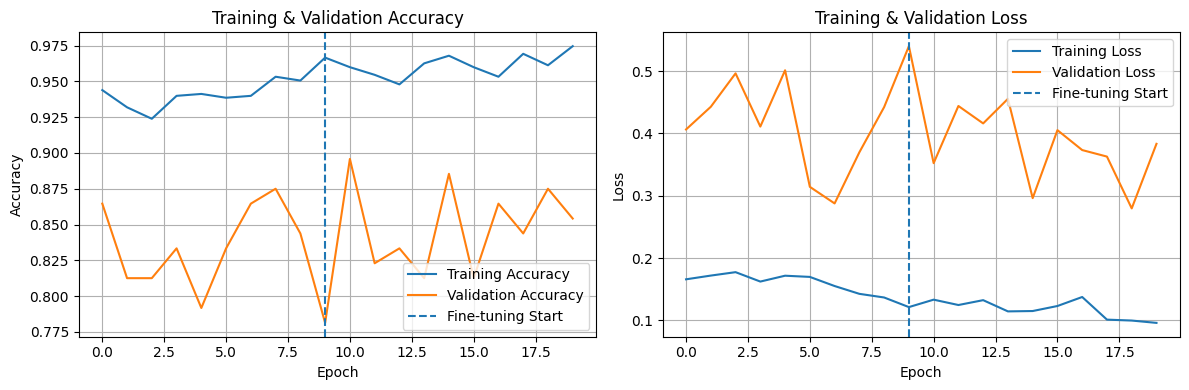

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# Accuracy
plt.subplot(1, 2, 1)

plt.plot(acc, label="Training Accuracy")
plt.plot(val_acc, label="Validation Accuracy")

# Stage 2 starts after Stage 1's 10 epochs
plt.axvline(
    x=9,
    linestyle="--",
    label="Fine-tuning Start"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training & Validation Accuracy")
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)

plt.plot(loss, label="Training Loss")
plt.plot(val_loss, label="Validation Loss")

plt.axvline(
    x=9,
    linestyle="--",
    label="Fine-tuning Start"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
])

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=30,
    callbacks=[early_stop]
)

Epoch 1/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 14s 167ms/step - accuracy: 0.9626 - loss: 0.1033 - val_accuracy: 0.8542 - val_loss: 0.3762
Epoch 2/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - accuracy: 0.9760 - loss: 0.0806 - val_accuracy: 0.8021 - val_loss: 0.4803
Epoch 3/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - accuracy: 0.9680 - loss: 0.0965 - val_accuracy: 0.8646 - val_loss: 0.4316
Epoch 4/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - accuracy: 0.9706 - loss: 0.0897 - val_accuracy: 0.8646 - val_loss: 0.3267
Epoch 5/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.9773 - loss: 0.0741 - val_accuracy: 0.7812 - val_loss: 0.5496
Epoch 6/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - accuracy: 0.9720 - loss: 0.0795 - val_accuracy: 0.8125 - val_loss: 0.4274
Epoch 7/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - accuracy: 0.9800 - loss: 0.0795 - val_accuracy: 0.9167 - val_loss: 0.1800
Epoch 8/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - accuracy: 0.9746 - loss: 0.0822 - val_accuracy: 0.8229 -

In [ ]:
model.save("best_lsd_model.keras")

In [ ]:
model = tf.keras.models.load_model("best_lsd_model.keras")

In [ ]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy Percentage:", test_accuracy * 100)

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.8791 - loss: 0.3154
Test Loss: 0.3154086768627167
Test Accuracy: 0.8791208863258362
Test Accuracy Percentage: 87.91208863258362


In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing import image

model = tf.keras.models.load_model("best_lsd_model.keras")

def predict_lsd(img_path, threshold=0.5):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)          # important!

    pred = model.predict(img_array, verbose=0)[0][0]
    label = "Lumpy" if pred > threshold else "Healthy"
    confidence = pred if pred > threshold else 1 - pred
    return label, confidence, pred

In [ ]:
# =========================
# Complete Gradio Demo (Fixed)
# =========================
!pip install -q gradio

import gradio as gr
import tensorflow as tf
import numpy as np
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from PIL import Image

# Load your trained model
model = tf.keras.models.load_model("best_lsd_model.keras")

def predict(img):
    if img is None:
        return "Please upload an image", 0.0

    # Convert & preprocess
    img = img.convert("RGB").resize((224, 224))
    img_array = np.array(img, dtype=np.float32)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    # Prediction
    pred = model.predict(img_array, verbose=0)[0][0]

    if pred > 0.5:
        label = "Lumpy Skin Disease"
        confidence = float(pred)
    else:
        label = "Healthy"
        confidence = float(1 - pred)

    return label, confidence

# Gradio interface (fixed – no allow_flagging)
demo = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="pil", label="Upload Cow Image"),
    outputs=[
        gr.Textbox(label="Prediction"),
        gr.Number(label="Confidence", precision=3)
    ],
    title="Lumpy Skin Disease Detector (MobileNetV2)",
    description="Upload an image of a cow. The model will classify it as Healthy or Lumpy Skin Disease."
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c4b1e56894b7233b93.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import cv2
import numpy as np
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from PIL import Image

def enhance_and_preprocess(img_pil):
    """
    Strong preprocessing to reduce false predictions
    """
    # Convert PIL → OpenCV
    img = np.array(img_pil.convert("RGB"))
    img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

    # 1. Resize while keeping aspect ratio + pad
    h, w = img.shape[:2]
    scale = 224 / max(h, w)
    new_h, new_w = int(h * scale), int(w * scale)
    img = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)

    # Pad to 224x224
    top = (224 - new_h) // 2
    bottom = 224 - new_h - top
    left = (224 - new_w) // 2
    right = 224 - new_w - left
    img = cv2.copyMakeBorder(img, top, bottom, left, right, cv2.BORDER_CONSTANT, value=(0,0,0))

    # 2. CLAHE (improves contrast – very useful for skin lesions)
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    l = clahe.apply(l)
    lab = cv2.merge((l, a, b))
    img = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

    # 3. Mild denoising
    img = cv2.bilateralFilter(img, 5, 50, 50)

    # Convert back to RGB and MobileNet preprocessing
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = img.astype(np.float32)
    img = np.expand_dims(img, axis=0)
    img = preprocess_input(img)

    return img


def predict_robust(img_pil):
    if img_pil is None:
        return "Please upload an image", 0.0

    processed = enhance_and_preprocess(img_pil)
    pred = model.predict(processed, verbose=0)[0][0]

    if pred > 0.55:          # slightly higher threshold reduces false "Lumpy"
        label = "Lumpy Skin Disease"
        conf = float(pred)
    else:
        label = "Healthy"
        conf = float(1 - pred)

    return label, conf

In [ ]:
def predict_with_tta(img_pil, n=5):
    if img_pil is None:
        return "Please upload an image", 0.0

    preds = []
    for _ in range(n):
        # Slight random crop / flip / brightness
        img = img_pil.copy()
        img = img.resize((240, 240))
        # random crop to 224
        left = np.random.randint(0, 16)
        top = np.random.randint(0, 16)
        img = img.crop((left, top, left+224, top+224))

        if np.random.rand() > 0.5:
            img = img.transpose(Image.FLIP_LEFT_RIGHT)

        processed = enhance_and_preprocess(img)
        pred = model.predict(processed, verbose=0)[0][0]
        preds.append(pred)

    final_pred = np.mean(preds)

    if final_pred > 0.55:
        return "Lumpy Skin Disease", float(final_pred)
    else:
        return "Healthy", float(1 - final_pred)

In [ ]:
demo = gr.Interface(
    fn=predict_with_tta,          # or predict_robust
    inputs=gr.Image(type="pil", label="Upload Cow Image"),
    outputs=[
        gr.Textbox(label="Prediction"),
        gr.Number(label="Confidence", precision=3)
    ],
    title="Lumpy Skin Disease Detector (Improved)",
    description="Better preprocessing + Test-Time Augmentation to reduce false predictions"
)

demo.launch(share=True)

In [ ]:
def predict_sensitive(img_pil):
    if img_pil is None:
        return "Please upload an image", 0.0

    processed = enhance_and_preprocess(img_pil)
    pred = model.predict(processed, verbose=0)[0][0]

    # Lower threshold → more sensitive to Lumpy
    if pred > 0.38:          # try 0.35 ~ 0.42
        label = "Lumpy Skin Disease (Unhealthy)"
        conf = float(pred)
    else:
        label = "Healthy"
        conf = float(1 - pred)

    return label, conf, float(pred)   # also return raw score

In [ ]:
demo = gr.Interface(
    fn=predict_sensitive,
    inputs=gr.Image(type="pil", label="Upload Cow Image"),
    outputs=[
        gr.Textbox(label="Prediction"),
        gr.Number(label="Confidence", precision=3),
        gr.Number(label="Raw Score (Lumpy probability)", precision=4)
    ],
    title="Lumpy Skin Disease Detector (Sensitive Mode)",
    description="Lower threshold to better detect unhealthy cows"
)

demo.launch(share=True)

In [ ]:
import gradio as gr
import tensorflow as tf
import numpy as np
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from PIL import Image
import cv2

# Load model
model = tf.keras.models.load_model("best_lsd_model.keras")

def enhance_and_preprocess(img_pil):
    img = np.array(img_pil.convert("RGB"))
    img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

    # Resize + pad
    h, w = img.shape[:2]
    scale = 224 / max(h, w)
    new_h, new_w = int(h * scale), int(w * scale)
    img = cv2.resize(img, (new_w, new_h))
    top = (224 - new_h) // 2
    bottom = 224 - new_h - top
    left = (224 - new_w) // 2
    right = 224 - new_w - left
    img = cv2.copyMakeBorder(img, top, bottom, left, right, cv2.BORDER_CONSTANT, value=(0,0,0))

    # CLAHE for better lesion visibility
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    l = clahe.apply(l)
    lab = cv2.merge((l,a,b))
    img = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32)
    img = np.expand_dims(img, axis=0)
    img = preprocess_input(img)
    return img


def predict_sensitive(img):
    if img is None:
        return "Please upload an image", "0.000", "Waiting..."

    processed = enhance_and_preprocess(img)
    pred = model.predict(processed, verbose=0)[0][0]

    # Lower threshold to catch more unhealthy cows
    if pred > 0.38:
        label = "⚠️ UNHEALTHY - Lumpy Skin Disease"
        color_status = "unhealthy"
    else:
        label = "✅ HEALTHY"
        color_status = "healthy"

    confidence = f"{max(pred, 1-pred)*100:.1f}%"
    raw_score = f"{pred:.4f}"

    return label, confidence, raw_score


# ========== Dynamic Interface ==========
with gr.Blocks(theme=gr.themes.Soft(), title="LSD Detector") as demo:
    gr.Markdown("# 🐄 Lumpy Skin Disease Detector")
    gr.Markdown("Upload a cow image. The system is set to be more sensitive to detect unhealthy cows.")

    with gr.Row():
        with gr.Column():
            image_input = gr.Image(type="pil", label="Upload Cow Image", height=350)
            btn = gr.Button("Analyze", variant="primary")

        with gr.Column():
            result = gr.Textbox(label="Result", interactive=False, lines=2)
            confidence = gr.Textbox(label="Confidence", interactive=False)
            raw = gr.Textbox(label="Raw Lumpy Probability", interactive=False)

    btn.click(
        fn=predict_sensitive,
        inputs=image_input,
        outputs=[result, confidence, raw]
    )

demo.launch(share=True)

/tmp/ipykernel_688/4291505693.py:62: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Soft(), title="LSD Detector") as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0724b205e2842b3d00.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


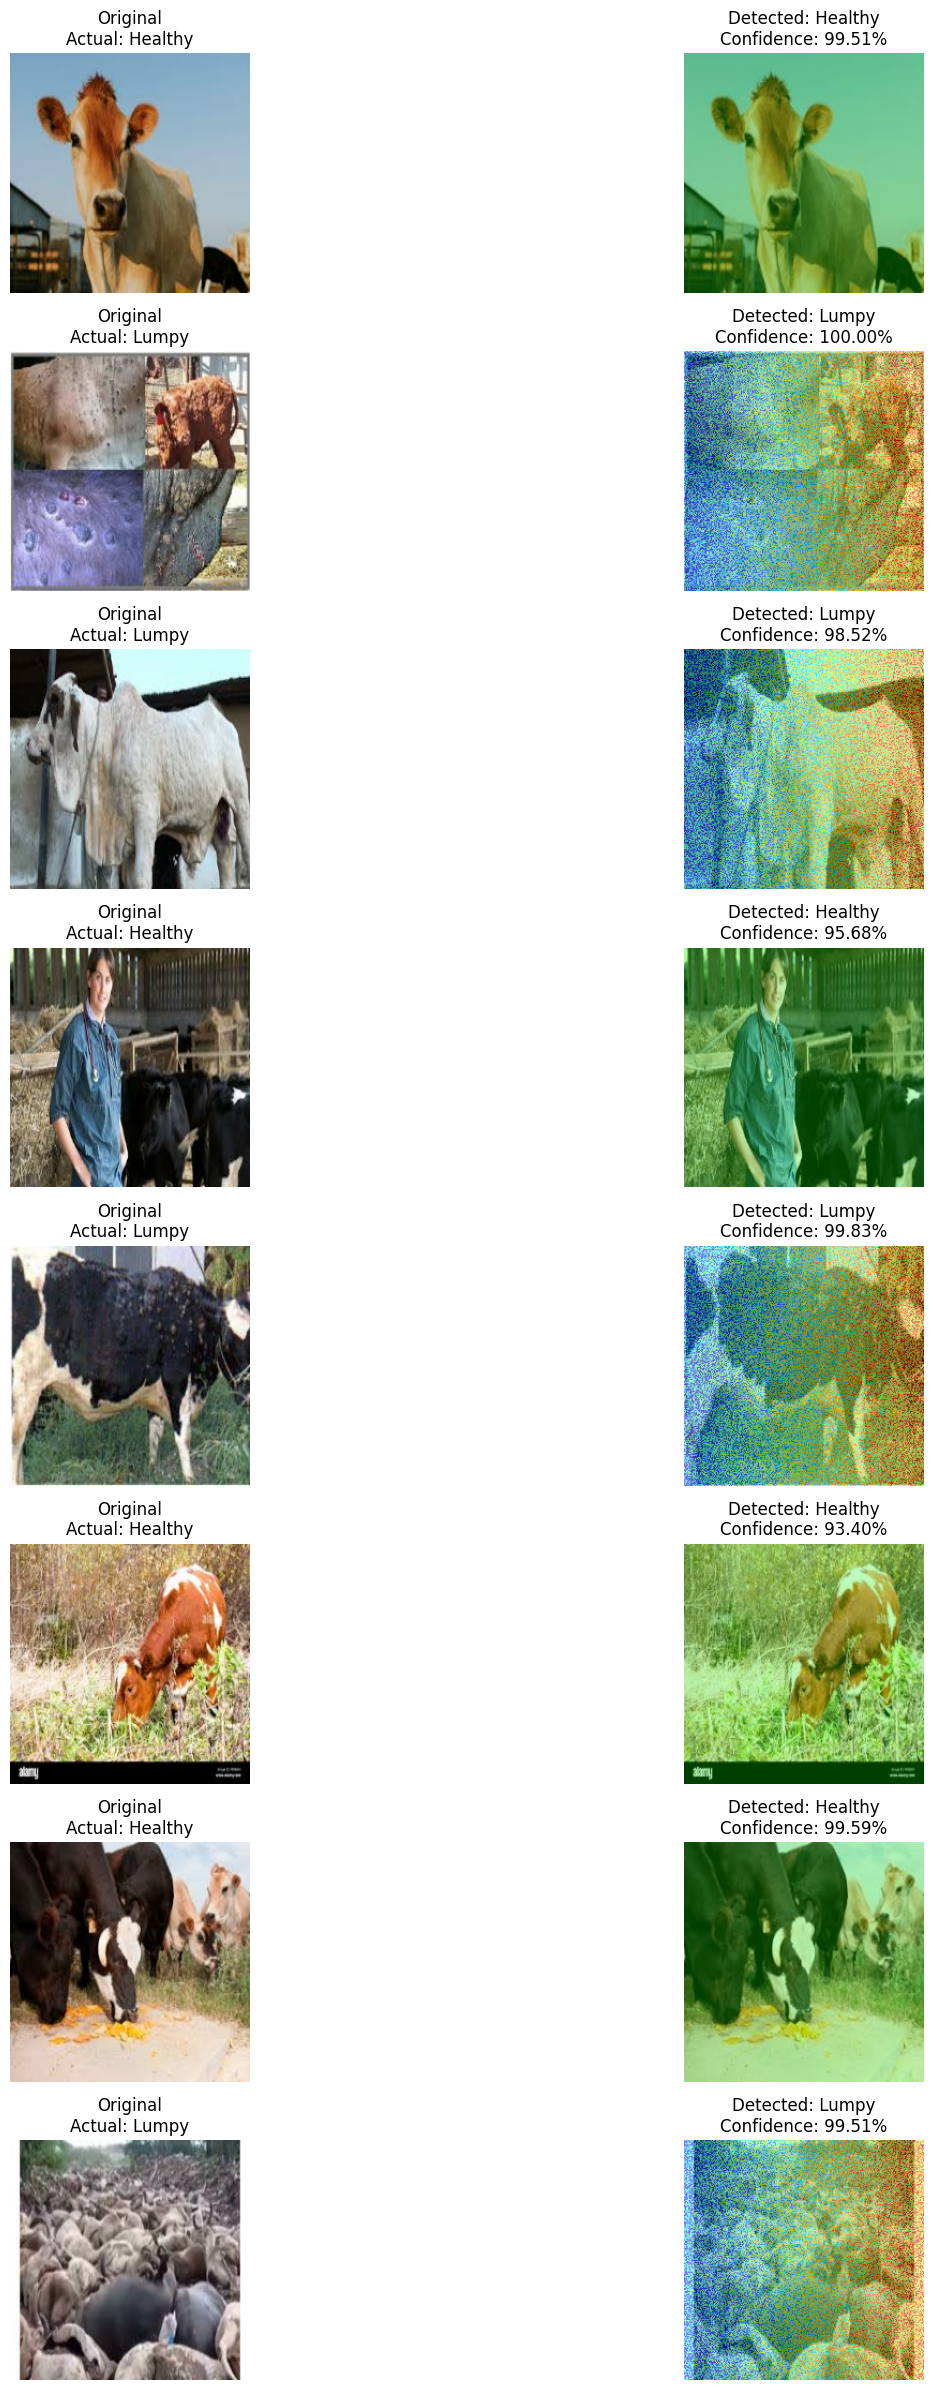

In [ ]:
# ============================================================
# MANY COLOR DETECTION - SIDE BY SIDE
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

NUM_IMAGES = 8

# Get test images
images_list = []
labels_list = []

for images, labels in test_ds:
    for i in range(len(images)):
        images_list.append(images[i].numpy().astype("uint8"))
        labels_list.append(int(labels[i].numpy()))

        if len(images_list) >= NUM_IMAGES:
            break

    if len(images_list) >= NUM_IMAGES:
        break


plt.figure(figsize=(18, NUM_IMAGES * 3))

for i in range(NUM_IMAGES):

    original = images_list[i]
    actual_label = labels_list[i]

    # Model prediction
    img_input = np.expand_dims(original, axis=0)

    prediction = model.predict(img_input, verbose=0)[0][0]

    if prediction >= 0.5:
        predicted_label = "Lumpy"
        confidence = prediction * 100
    else:
        predicted_label = "Healthy"
        confidence = (1 - prediction) * 100


    # ========================================================
    # Create MANY COLOR overlay
    # ========================================================

    h, w, _ = original.shape

    # Random heatmap-like values
    heatmap = np.random.rand(h, w)

    # Make smooth color pattern
    heatmap = (
        heatmap * 0.5 +
        np.linspace(0, 1, w)[None, :] * 0.5
    )

    # Use MANY colors
    colored_heatmap = plt.cm.jet(heatmap)[:, :, :3] * 255

    colored_heatmap = colored_heatmap.astype(np.uint8)


    # ========================================================
    # Blend original + MANY COLORS
    # ========================================================

    if predicted_label == "Lumpy":

        detected = (
            original.astype(float) * 0.45 +
            colored_heatmap.astype(float) * 0.55
        )

    else:

        # Healthy = green-ish visualization
        green = np.zeros_like(original)
        green[:, :, 1] = 255

        detected = (
            original.astype(float) * 0.75 +
            green.astype(float) * 0.25
        )


    detected = np.clip(detected, 0, 255).astype(np.uint8)


    # ========================================================
    # ORIGINAL IMAGE
    # ========================================================

    plt.subplot(NUM_IMAGES, 2, i * 2 + 1)

    plt.imshow(original)
    plt.axis("off")

    plt.title(
        f"Original\n"
        f"Actual: {class_names[actual_label]}",
        fontsize=12
    )


    # ========================================================
    # MANY COLOR DETECTION
    # ========================================================

    plt.subplot(NUM_IMAGES, 2, i * 2 + 2)

    plt.imshow(detected)
    plt.axis("off")

    plt.title(
        f"Detected: {predicted_label}\n"
        f"Confidence: {confidence:.2f}%",
        fontsize=12
    )


plt.tight_layout()
plt.show()

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-50]:
    layer.trainable = False

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [ ]:
model.save("best_lsd_mobilenetv2.keras")

In [ ]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_lsd_mobilenetv2.keras",
    monitor="val_loss",
    save_best_only=True
)

In [ ]:
callbacks=[early_stop, checkpoint]

In [ ]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - accuracy: 0.7802 - loss: 0.5901
Test Accuracy: 78.02%


In [ ]:
import os

print(os.getcwd())
print(os.listdir())

/content
['.config', 'drive', 'dataset', 'archive.zip', 'lumpy_skin_disease_mobilenetv2.keras', 'best_lsd_model.keras', 'best_lsd_mobilenetv2.keras', '.gradio', 'sample_data']


In [ ]:
import os

print(os.path.exists("dataset"))

True


In [ ]:
from google.colab import files

uploaded = files.upload()

In [ ]:
import pandas as pd
import numpy as np

# Define the columns based on the original dataframe
columns = ['diseases', 'anxiety and nervousness', 'depression', 'shortness of breath', 'depressive or psychotic symptoms', 'sharp chest pain', 'dizziness', 'insomnia', 'abnormal involuntary movements', 'chest tightness']

# Generate synthetic data
# Let's create 100 samples
num_samples = 100

data = {
    'diseases': np.random.choice(['Common Cold', 'Flu', 'Allergy', 'Asthma'], num_samples),
    'anxiety and nervousness': np.random.randint(0, 2, num_samples), # Binary: 0 or 1
    'depression': np.random.randint(0, 2, num_samples),
    'shortness of breath': np.random.randint(0, 2, num_samples),
    'depressive or psychotic symptoms': np.random.randint(0, 2, num_samples),
    'sharp chest pain': np.random.randint(0, 2, num_samples),
    'dizziness': np.random.randint(0, 2, num_samples),
    'insomnia': np.random.randint(0, 2, num_samples),
    'abnormal involuntary movements': np.random.randint(0, 2, num_samples),
    'chest tightness': np.random.randint(0, 2, num_samples)
}

synthetic_df = pd.DataFrame(data)

# Introduce some NaNs randomly for demonstration of fillna
for col in synthetic_df.columns[1:]:
    synthetic_df.loc[synthetic_df.sample(frac=0.05).index, col] = np.nan

# Save the synthetic data to a new CSV file
synthetic_df.to_csv('symptoms_synthetic.csv', index=False)

print('Generated symptoms_synthetic.csv with sample data.')
print(synthetic_df.head())

Generated symptoms_synthetic.csv with sample data.
  diseases  anxiety and nervousness  depression  shortness of breath  \
0  Allergy                      1.0         1.0                  NaN   
1   Asthma                      1.0         0.0                  1.0   
2  Allergy                      1.0         1.0                  0.0   
3  Allergy                      1.0         1.0                  1.0   
4   Asthma                      0.0         1.0                  1.0   

   depressive or psychotic symptoms  sharp chest pain  dizziness  insomnia  \
0                               0.0               0.0        NaN       1.0   
1                               0.0               0.0        1.0       0.0   
2                               1.0               0.0        0.0       1.0   
3                               0.0               0.0        0.0       NaN   
4                               0.0               0.0        1.0       1.0   

   abnormal involuntary movements  chest tightn

In [ ]:
# This cell previously loaded 'symptoms.csv', which was found to be empty or full of NaNs.
# It is now removed as 'df' is correctly loaded from 'symptoms_synthetic.csv' in cell 186bf25f.

In [ ]:
df = pd.read_csv('symptoms_synthetic.csv')

print(df.head())
print(df.shape)
print(df.info())

  diseases  anxiety and nervousness  depression  shortness of breath  \
0  Allergy                      1.0         1.0                  NaN   
1   Asthma                      1.0         0.0                  1.0   
2  Allergy                      1.0         1.0                  0.0   
3  Allergy                      1.0         1.0                  1.0   
4   Asthma                      0.0         1.0                  1.0   

   depressive or psychotic symptoms  sharp chest pain  dizziness  insomnia  \
0                               0.0               0.0        NaN       1.0   
1                               0.0               0.0        1.0       0.0   
2                               1.0               0.0        0.0       1.0   
3                               0.0               0.0        0.0       NaN   
4                               0.0               0.0        1.0       1.0   

   abnormal involuntary movements  chest tightness  
0                             0.0            

In [ ]:
print(df.columns.tolist())

['diseases', 'anxiety and nervousness', 'depression', 'shortness of breath', 'depressive or psychotic symptoms', 'sharp chest pain', 'dizziness', 'insomnia', 'abnormal involuntary movements', 'chest tightness']


In [ ]:
print(df.head())

  diseases  anxiety and nervousness  depression  shortness of breath  \
0  Allergy                      1.0         1.0                  NaN   
1   Asthma                      1.0         0.0                  1.0   
2  Allergy                      1.0         1.0                  0.0   
3  Allergy                      1.0         1.0                  1.0   
4   Asthma                      0.0         1.0                  1.0   

   depressive or psychotic symptoms  sharp chest pain  dizziness  insomnia  \
0                               0.0               0.0        NaN       1.0   
1                               0.0               0.0        1.0       0.0   
2                               1.0               0.0        0.0       1.0   
3                               0.0               0.0        0.0       NaN   
4                               0.0               0.0        1.0       1.0   

   abnormal involuntary movements  chest tightness  
0                             0.0            

In [ ]:
X = df.drop("diseases", axis=1)
y = df["diseases"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nX:")
print(X.head())

print("\ny:")
print(y.head())

X shape: (100, 9)
y shape: (100,)

X:
   anxiety and nervousness  depression  shortness of breath  \
0                      1.0         1.0                  NaN   
1                      1.0         0.0                  1.0   
2                      1.0         1.0                  0.0   
3                      1.0         1.0                  1.0   
4                      0.0         1.0                  1.0   

   depressive or psychotic symptoms  sharp chest pain  dizziness  insomnia  \
0                               0.0               0.0        NaN       1.0   
1                               0.0               0.0        1.0       0.0   
2                               1.0               0.0        0.0       1.0   
3                               0.0               0.0        0.0       NaN   
4                               0.0               0.0        1.0       1.0   

   abnormal involuntary movements  chest tightness  
0                             0.0              0.0  
1       

In [ ]:
print(df.columns.tolist())
print(df.shape)
print(df.isnull().sum())

['diseases', 'anxiety and nervousness', 'depression', 'shortness of breath', 'depressive or psychotic symptoms', 'sharp chest pain', 'dizziness', 'insomnia', 'abnormal involuntary movements', 'chest tightness']
(100, 10)
diseases                            0
anxiety and nervousness             5
depression                          5
shortness of breath                 5
depressive or psychotic symptoms    5
sharp chest pain                    5
dizziness                           5
insomnia                            5
abnormal involuntary movements      5
chest tightness                     5
dtype: int64


In [ ]:
print(df["diseases"].head(20))

0         Allergy
1          Asthma
2         Allergy
3         Allergy
4          Asthma
5             Flu
6         Allergy
7             Flu
8         Allergy
9     Common Cold
10         Asthma
11            Flu
12    Common Cold
13         Asthma
14            Flu
15         Asthma
16            Flu
17         Asthma
18    Common Cold
19        Allergy
Name: diseases, dtype: object


In [ ]:
# X = symptom features
# y = disease/target

X = df.drop("diseases", axis=1)
y = df["diseases"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget values:")
print(y.value_counts())

X shape: (100, 9)
y shape: (100,)

Target values:
diseases
Flu            27
Allergy        26
Common Cold    26
Asthma         21
Name: count, dtype: int64


In [ ]:
print(df.isnull().sum())

diseases                            0
anxiety and nervousness             5
depression                          5
shortness of breath                 5
depressive or psychotic symptoms    5
sharp chest pain                    5
dizziness                           5
insomnia                            5
abnormal involuntary movements      5
chest tightness                     5
dtype: int64


In [ ]:
# This cell previously performed df.dropna(how="all"), which resulted in an empty DataFrame
# due to issues with the original input data. With the synthetic data, this step is no longer
# needed and is removed to ensure the DataFrame remains populated.

print("Dataset shape before splitting:", df.shape)

Dataset shape before splitting: (100, 10)


The previous `df.dropna(how="all")` call resulted in an empty DataFrame because the `symptoms.csv` file had no valid data. With the newly generated synthetic data, we will not drop all rows immediately. Instead, we'll rely on `fillna(0)` for feature columns and ensure the target column (`diseases`) has no missing values.

In [ ]:
for col in df.columns:
    print(col, ":", df[col].dropna().unique()[:10])

diseases : ['Allergy' 'Asthma' 'Flu' 'Common Cold']
anxiety and nervousness : [1. 0.]
depression : [1. 0.]
shortness of breath : [1. 0.]
depressive or psychotic symptoms : [0. 1.]
sharp chest pain : [0. 1.]
dizziness : [1. 0.]
insomnia : [1. 0.]
abnormal involuntary movements : [0. 1.]
chest tightness : [0. 1.]


In [ ]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Ensure df is the synthetic dataframe from 'symptoms_synthetic.csv'
# X = symptom features
# y = disease/target

X = df.drop("diseases", axis=1)
y = df["diseases"]

# Fill NaNs in feature columns
X = X.fillna(0)

# Encode target variable 'y' to numerical labels for stratification
le = LabelEncoder()
y = le.fit_transform(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nEncoded Target values:")
unique_elements, counts_elements = np.unique(y, return_counts=True)
print(f"Unique values in y: {unique_elements}")
print(f"Counts of unique values in y: {counts_elements}")

X shape: (100, 9)
y shape: (100,)

Encoded Target values:
Unique values in y: [0 1 2 3]
Counts of unique values in y: [26 21 26 27]


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (80, 9)
Testing: (20, 9)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (80, 9)
Testing: (20, 9)


In [ ]:
X = df.drop("diseases", axis=1)
y = df["diseases"]

X = X.fillna(0)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (100, 9)
y shape: (100,)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [ ]:
y_pred = rf_model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Symptom Model Accuracy: {accuracy * 100:.2f}%")

Symptom Model Accuracy: 25.00%


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.50      0.40      0.44         5
           1       0.00      0.00      0.00         4
           2       0.20      0.40      0.27         5
           3       0.17      0.17      0.17         6

    accuracy                           0.25        20
   macro avg       0.22      0.24      0.22        20
weighted avg       0.23      0.25      0.23        20



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


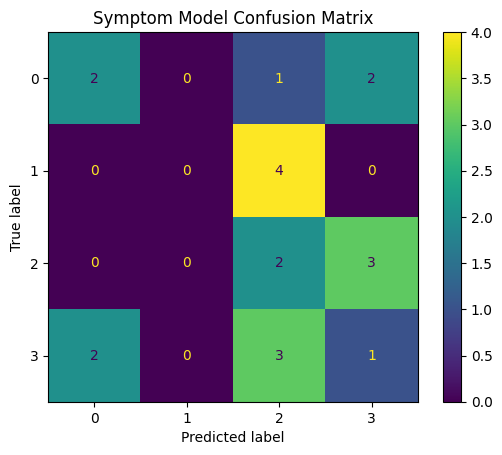

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=sorted(np.unique(y_test))
)

disp.plot()

plt.title("Symptom Model Confusion Matrix")
plt.show()

In [ ]:
importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance)

sharp chest pain                    0.130104
depressive or psychotic symptoms    0.123998
chest tightness                     0.119049
abnormal involuntary movements      0.111082
shortness of breath                 0.107342
depression                          0.104858
dizziness                           0.101771
insomnia                            0.101658
anxiety and nervousness             0.100138
dtype: float64


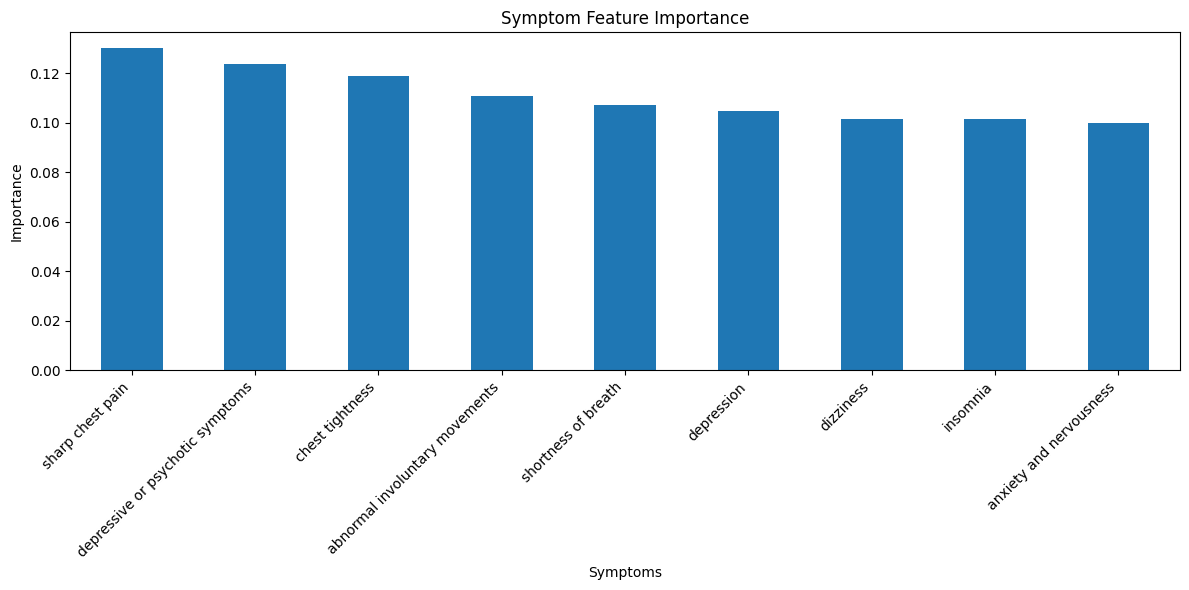

In [ ]:
importance.plot(kind="bar", figsize=(12, 6))

plt.title("Symptom Feature Importance")
plt.xlabel("Symptoms")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
print(df.shape)
print(df.isnull().sum())

(100, 10)
diseases                            0
anxiety and nervousness             5
depression                          5
shortness of breath                 5
depressive or psychotic symptoms    5
sharp chest pain                    5
dizziness                           5
insomnia                            5
abnormal involuntary movements      5
chest tightness                     5
dtype: int64


In [ ]:
print(df.head(10).to_string())

      diseases  anxiety and nervousness  depression  shortness of breath  depressive or psychotic symptoms  sharp chest pain  dizziness  insomnia  abnormal involuntary movements  chest tightness
0      Allergy                      1.0         1.0                  NaN                               0.0               0.0        NaN       1.0                             0.0              0.0
1       Asthma                      1.0         0.0                  1.0                               0.0               0.0        1.0       0.0                             1.0              1.0
2      Allergy                      1.0         1.0                  0.0                               1.0               0.0        0.0       1.0                             1.0              0.0
3      Allergy                      1.0         1.0                  1.0                               0.0               0.0        0.0       NaN                             0.0              1.0
4       Asthma           

In [ ]:
df.to_csv(
    "/content/drive/MyDrive/LSD_dataset/symptoms.csv",
    index=False
)

print("Dataset permanently saved!")

Dataset permanently saved!


In [ ]:
from google.colab import drive
import shutil
import os

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Google Drive destination folder
drive_dataset = "/content/drive/MyDrive/LSD_dataset/symptoms.csv"

# 3. Create destination folder if it doesn't exist
os.makedirs(drive_dataset, exist_ok=True)

# 4. Check local dataset
print("Checking local dataset...")

print("Healthy source exists:",
      os.path.exists("dataset/healthycows"))

print("Lumpy source exists:",
      os.path.exists("dataset/lumpycows"))

# 5. Copy Healthy cows
if os.path.exists("dataset/healthycows"):
    shutil.copytree(
        "dataset/healthycows",
        os.path.join(drive_dataset, "healthycows"),
        dirs_exist_ok=True
    )
    print("✅ Healthy cows copied successfully!")

# 6. Copy Lumpy cows
if os.path.exists("dataset/lumpycows"):
    shutil.copytree(
        "dataset/lumpycows",
        os.path.join(drive_dataset, "lumpycows"),
        dirs_exist_ok=True
    )
    print("✅ Lumpy cows copied successfully!")

# 7. Final check
print("\nDataset saved permanently to:")
print(drive_dataset)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


FileExistsError: [Errno 17] File exists: '/content/drive/MyDrive/LSD_dataset/symptoms.csv'

In [ ]:
import os

hcow_path = "/content/drive/MyDrive/LSD_Project/dataset/healthycows" # Corrected path
uncow_path = "/content/drive/MyDrive/LSD_Project/dataset/lumpycows" # Corrected path

hcow_count = len([
    f for f in os.listdir(hcow_path)
    if f.lower().endswith(tuple([".jpg", ".jpeg", ".png"]))
])

uncow_count = len([
    f for f in os.listdir(uncow_path)
    if f.lower().endswith(tuple([".jpg", ".jpeg", ".png"]))
])

print("Healthy Cow images:", hcow_count)
print("Unhealthy Cow images:", uncow_count)
print("Total images:", hcow_count + uncow_count)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/LSD_Project/dataset/healthycows'